In [2]:
#to run on your machine, you'll need to change the directories specified in 
#NeuralDecoder/neuralDecoder/configs/dataset/speech_release_baseline.yaml
#and change "outputDir" specified below

import os
baseDir = 'C:/Users/krishna/Documents/NeuroSpeech/speechBCI-main'
os.makedirs(baseDir+'/derived/rnns', exist_ok=True)

In [2]:
import tensorflow as tf

print("TF version:", tf.__version__)
print("Available devices:")
for d in tf.config.list_physical_devices():
    print(d)

TF version: 2.10.0
Available devices:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [3]:
%run C:/Users/krishna/Documents/NeuroSpeech/speechBCI-main/NeuralDecoder/neuralDecoder/main.py dataset=speech_release_baseline model=gru_stack_inputNet learnRateDecaySteps=10000 nBatchesToTrain=100 learnRateStart=0.02 model.nUnits=1024 model.stack_kwargs.kernel_size=32 -- "outputDir=C:/Users/krishna/Documents/speechBCI-main/derived/rnns/baselineRelease"

C:\Users\krishna\Documents\NeuroSpeech\speechBCI-main\NeuralDecoder\neuralDecoder\main.py:10: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path='configs', config_name='config')
c:\Users\krishna\AppData\Local\Programs\Python\Python39\lib\site-packages\hydra\_internal\defaults_list.py:251: UserWarning: In 'config': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


Setting CUDA_VISIBLE_DEVICES to 0
Output dir C:/Users/krishna/Documents/speechBCI-main/derived/rnns/baselineRelease
[2025-10-15 21:10:17,893][tensorflow][WARNING] - Layer gru_1 will not use cuDNN kernels since it doesn't meet the criteria. It will use a generic GPU kernel as fallback when running on GPU.
[2025-10-15 21:10:17,896][tensorflow][WARNING] - Layer gru_2 will not use cuDNN kernels since it doesn't meet the criteria. It will use a generic GPU kernel as fallback when running on GPU.
[2025-10-15 21:10:17,898][tensorflow][WARNING] - Layer gru_3 will not use cuDNN kernels since it doesn't meet the criteria. It will use a generic GPU kernel as fallback when running on GPU.
[2025-10-15 21:10:17,900][tensorflow][WARNING] - Layer gru_4 will not use cuDNN kernels since it doesn't meet the criteria. It will use a generic GPU kernel as fallback when running on GPU.
[2025-10-15 21:10:17,903][tensorflow][WARNING] - Layer gru_5 will not use cuDNN kernels since it doesn't meet the criteria. 

c:\Users\krishna\AppData\Local\Programs\Python\Python39\lib\site-packages\hydra\_internal\hydra.py:119: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(
c:\Users\krishna\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\initializers\initializers_v2.py:120: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(
c:\Users\krishna\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\initializers\initializers_v2.py:120: UserWarning: The initializer Orthogonal is unseeded and being called multiple times, which will return identical values  each time 

Model: "gru"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_1 (GRU)                 multiple                  28314624  
                                                                 
 gru_2 (GRU)                 multiple                  6294528   
                                                                 
 gru_3 (GRU)                 multiple                  6294528   
                                                                 
 gru_4 (GRU)                 multiple                  6294528   
                                                                 
 gru_5 (GRU)                 multiple                  6294528   
                                                                 
 dense (Dense)               multiple                  42025     
                                                                 
Total params: 53,535,785
Trainable params: 53,535,785
Non-train

dict_keys(['__header__', '__version__', '__globals__', 'logitsSnapshot', 'inputFeaturesSnapshot', 'perBatchData_train', 'perBatchData_val', 'seqIDs'])


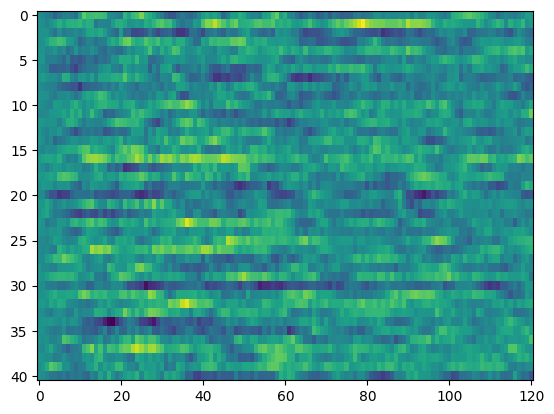

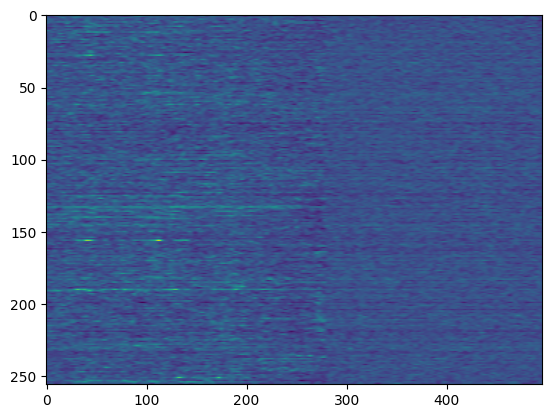

(496, 256)

In [4]:
#we can visualize the logits and the input features here as a sanity check by loading the output snapshot file
import scipy.io
dat = scipy.io.loadmat(baseDir+'\out\out\outputSnapshot')
print(dat.keys())

dat['logitsSnapshot'].shape
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.imshow(dat['logitsSnapshot'].T, aspect='auto')
plt.show()

plt.figure()
plt.imshow(dat['inputFeaturesSnapshot'].T, aspect='auto')
plt.show()

dat['inputFeaturesSnapshot'].shape